In [13]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"

In [14]:
import torch
import matplotlib.pyplot as plt
from custom_vision_transformer import vit_custom_16
from training_parameters import d_params
from train_utils import *
from torchvision.models.feature_extraction import create_feature_extractor
from PIL import Image
from torchvision import transforms

In [15]:
print("Nombre de GPUs visibles :", torch.cuda.device_count())

gpu_idx = 1
torch.cuda.set_device(gpu_idx)

# --- device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print("GPU visible :", torch.cuda.current_device())
print("GPU name :", torch.cuda.get_device_name(torch.cuda.current_device()))

Nombre de GPUs visibles : 3
Device: cuda
GPU visible : 1
GPU name : NVIDIA GeForce RTX 2080


In [16]:
batch_size = d_params["batch_size"]
img_size = d_params["img_size"]
num_classes = d_params["num_classes"]

In [21]:
model = vit_custom_16(num_classes=num_classes, attention_bias=True).to(device)
model.load_state_dict(torch.load("./training_checkpoints/vit_custom_16_epoch_30.pth"))
model.eval();

In [22]:
Wb = model.encoder.layers[3].self_attention.b.weight
print(Wb.shape, Wb.min().item(), Wb.max().item(), Wb.mean().item(), Wb.std().item())

print(model.encoder.layers[3].self_attention.b.bias.shape)

torch.Size([6, 384]) -0.014752533286809921 0.017672628164291382 5.124430390424095e-05 0.0048645976930856705
torch.Size([6])


In [70]:
# --- modify self_attention to store attention weights ---
for layer in model.encoder.layers:
    orig_forward = layer.self_attention.forward

    def new_forward(*args, orig_forward=orig_forward, layer=layer, **kwargs):
        out, attn = orig_forward(*args, **kwargs)
        layer.attn_weights = attn.detach()  # store the attention matrix
        return out, attn

    layer.self_attention.forward = new_forward

In [71]:
# --- create feature extractor ---
return_nodes = {f"encoder.layers.encoder_layer_{i}": f"block_{i}" for i in range(len(model.encoder.layers))}
return_nodes["heads.head"] = "output_layer"

feature_extractor = create_feature_extractor(model, return_nodes)

In [7]:
# --- prepare image ---
img = "img2"
image = Image.open("data/n01558993/n01558993_5.JPEG").convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize( # mean and std for ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

tensor = transform(image)
tensor = tensor.unsqueeze(0) # add the batch dimension

In [8]:
#out = feature_extractor(tensor.to(device))  # run a forward pass to get intermediate values
_ = model(tensor.to(device))  # run a forward pass to populate attention weights

qk mean/std: 0.025713002309203148 0.30804529786109924
bias mean/std: -0.04371905326843262 0.47154074907302856


NameError: name 'stop' is not defined

In [74]:
attentions = [layer.attn_weights for layer in model.encoder.layers]

In [75]:
for i, attn in enumerate(attentions):
    print(f"Attention layer {i} shape: {attn.shape}")

Attention layer 0 shape: torch.Size([1, 6, 197, 197])
Attention layer 1 shape: torch.Size([1, 6, 197, 197])
Attention layer 2 shape: torch.Size([1, 6, 197, 197])
Attention layer 3 shape: torch.Size([1, 6, 197, 197])
Attention layer 4 shape: torch.Size([1, 6, 197, 197])
Attention layer 5 shape: torch.Size([1, 6, 197, 197])


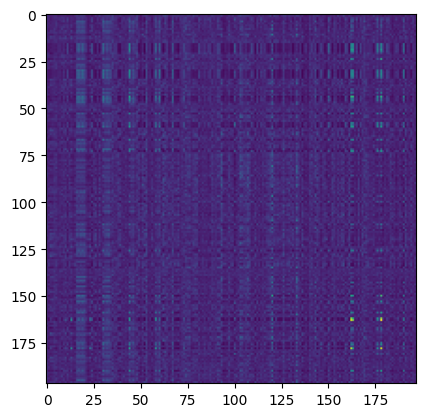

In [78]:
# --- attention map of all layers averaged across heads ---
attentions_avg = [attn.mean(dim=1) for attn in attentions]  # average over heads
for i in range(6):
    plt.imshow(attentions_avg[i][0].cpu())
    plt.savefig(f"attention_maps/{img}/attention_maps_img/attention_map_{i}")

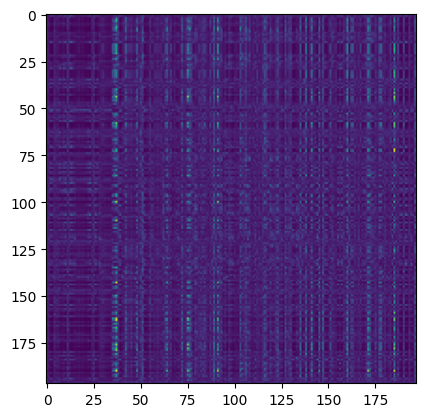

In [79]:
# --- attention map of all heads from layer num_layer --- (only works if average_attn_weights=False in new_forward)
num_layer = 3
for i in range(6):
    plt.imshow(attentions[num_layer][0,i,:,:].cpu())
    plt.savefig(f"attention_maps/{img}/attention_maps_all_heads_layer{num_layer}/attention_map_{i}")